In [1]:
# Cell 1: imports and config
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Allow imports from project root
import sys
sys.path.insert(0, str(Path.cwd().parent))

pd.set_option("display.max_colwidth", 200)
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
# Cell 2: load the data
path = Path("../data/raw/pcmb_500.jsonl")
records = [json.loads(line) for line in path.open()]
df = pd.DataFrame(records)
print(f"Loaded {len(df)} questions")
df.head(2)

Loaded 500 questions


,id,question,options,answer_index,answer_letter,subject,source,source_id
0,ee80e03e020981af,"Each of the four jet engines on an Airbus A380 airliner develops athrust (a forward force on the airliner) of 322,000 N (72,000 lb).When the airplane is flying at 250 m/s, what horsepower does eac...","[85000, 130000, 120000, 115000, 108000, 140000, 75000, 70000, 100000, 95000]",4,E,physics,mmlu-pro,10336
1,0ad25c072278494a,Spring scales are used to measure the net force applied to an object; a sonic motion detector is used to measure the object’s resulting acceleration. A graph is constructed with the net force on t...,"[Inertial mass, Gravitational mass, Kinetic energy, Velocity, Weight, Friction, Force, Momentum, Distance, Speed]",0,A,physics,mmlu-pro,9304


subject
physics      125
chemistry    125
biology      125
math         125
Name: count, dtype: int64


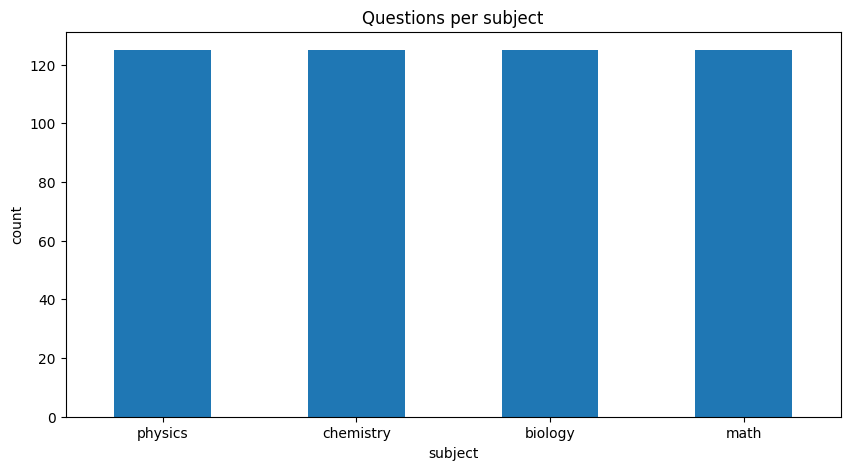

In [3]:
# Cell 3: subject balance
counts = df["subject"].value_counts()
print(counts)
counts.plot(kind="bar", title="Questions per subject")
plt.ylabel("count")
plt.xticks(rotation=0)
plt.show()

answer_letter   A   B   C   D   E   F   G   H   I   J
subject                                              
biology        13  13  13  14   9  12  18   9  17   7
chemistry      17  13  12  12  15   5  13  16   9  13
math           11  16  14  14   6  10  18  10  13  13
physics        17   8  14  14  16  15   4   6  14  17


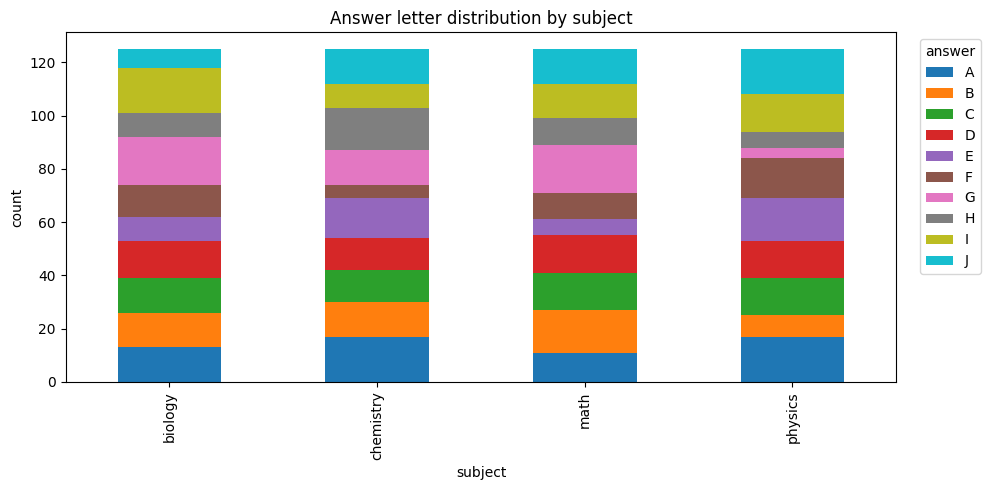

In [4]:
# Cell 4: answer letter distribution per subject — sanity check for biases
# A heavily skewed distribution (e.g. 50% of biology answers are 'A') means MMLU-Pro
# has a positional bias and the model could shortcut without reasoning.
answer_dist = (
    df.groupby("subject")["answer_letter"]
      .value_counts()
      .unstack(fill_value=0)
      .reindex(columns=list("ABCDEFGHIJ"), fill_value=0)
)
print(answer_dist)

ax = answer_dist.plot(kind="bar", stacked=True, title="Answer letter distribution by subject")
ax.set_ylabel("count")
plt.legend(title="answer", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

count    500.000000
mean      32.692000
std       20.340812
min        3.000000
25%       16.000000
50%       29.000000
75%       44.000000
max      118.000000
Name: q_words, dtype: float64


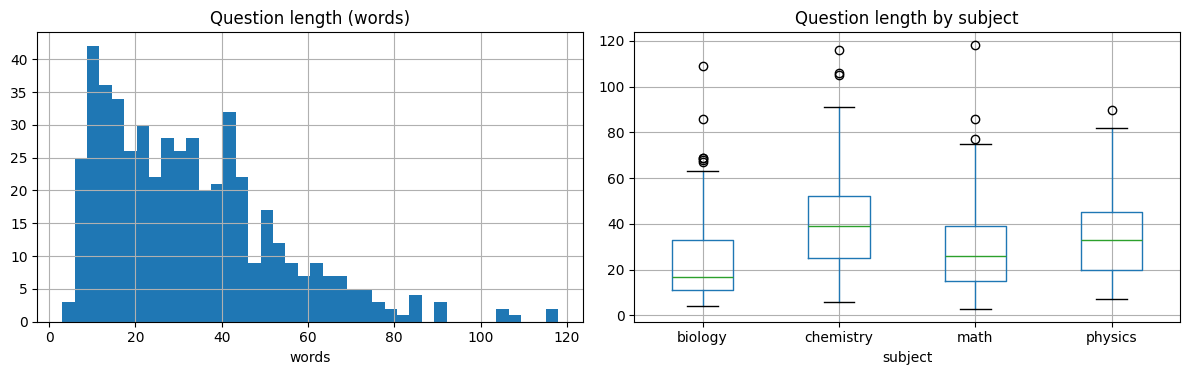


Too short (<15 words): 106
Too long  (>250 words): 0

Shortest questions:
       subject  q_words                                               question
412       math        3                                Which statementis true?
348    biology        4  Define the termsAnthropoidea,Hominidaeand Hominoidea?
328    biology        5                      Describe the development of seed.
229  chemistry        6              The Pauli exclusion principle states that
285    biology        6               Gene flow between populations results in


In [5]:
# Cell 5: question length distribution
# Short questions (<20 words) are usually too easy or malformed.
# Very long questions (>300 words) can blow the context budget during training.
df["q_words"] = df["question"].str.split().str.len()
df["q_chars"] = df["question"].str.len()
print(df["q_words"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["q_words"].hist(bins=40, ax=axes[0])
axes[0].set_title("Question length (words)")
axes[0].set_xlabel("words")
df.boxplot(column="q_words", by="subject", ax=axes[1])
axes[1].set_title("Question length by subject")
plt.suptitle("")
plt.tight_layout()
plt.show()

# Flag any too-short or too-long questions
short = df[df["q_words"] < 15]
long = df[df["q_words"] > 250]
print(f"\nToo short (<15 words): {len(short)}")
print(f"Too long  (>250 words): {len(long)}")
if len(short) > 0:
    print("\nShortest questions:")
    print(short.nsmallest(5, "q_words")[["subject", "q_words", "question"]])

In [6]:
# Cell 6: number of options per question
df["n_options"] = df["options"].apply(len)
print(df["n_options"].value_counts())
# MMLU-Pro standard is 10 options. Anything else is a schema issue worth investigating.

n_options
10    458
9      20
4      11
8       4
7       3
6       2
5       2
Name: count, dtype: int64


In [7]:
# Cell 7: inspect 3 random questions per subject manually
# Reading the data is the single most important thing you can do.
# 70% of dataset bugs are found this way.
rng = np.random.default_rng(0)
for subject in ["physics", "chemistry", "biology", "math"]:
    print("=" * 80)
    print(f"  {subject.upper()}")
    print("=" * 80)
    subset = df[df["subject"] == subject]
    sample_idx = rng.choice(len(subset), size=3, replace=False)
    for idx in sample_idx:
        row = subset.iloc[idx]
        print(f"\n[{row['id']}] correct answer: {row['answer_letter']}")
        print(row["question"])
        for i, opt in enumerate(row["options"]):
            marker = " <- correct" if i == row["answer_index"] else ""
            print(f"  {'ABCDEFGHIJ'[i]}. {opt}{marker}")
        print()

  PHYSICS

[f0ce5db8c14c749c] correct answer: F
How much heat is produced in 5 minutes by an electric iron which draws 5 amperes from a 120-volt line?
  A. 72,000 calories
  B. 80,000 calories
  C. 36,000 calories
  D. 65,000 calories
  E. 48,000 calories
  F. 43,000 calories <- correct
  G. 60,000 calories
  H. 50,000 calories
  I. 54,000 calories
  J. 30,000 calories


[c5c515dd676bdee1] correct answer: F
A coil of 60 ohms inductive reactance in series with a resistance of 25 ohms is connected to an a-c line of 130 volts. What will be the current through the circuit?
  A. 2.5 amp
  B. 0.5 amp
  C. 2.8 amp
  D. 3.0 amp
  E. 1.0 amp
  F. 2.0 amp <- correct
  G. 1.5 amp
  H. 4.0 amp
  I. 3.5 amp
  J. 1.2 amp


[fd9dd2d4e84533b2] correct answer: J
Acompressionalwave of frequency 250/sec is set up in an iron rod and passes from the rod into air. The speed of the wave is 1.6 x 10^4 ft/sec in iron and 1.1 x 10^3 ft/sec in air. Find the wavelength in each material.
  A. 70 ft in iron, 3.5 ft

In [8]:
# Cell 8: ID uniqueness (catch any dedup bugs)
assert df["id"].is_unique, "Duplicate IDs found!"
print("All 500 IDs unique ✓")

# Also check question-text uniqueness (different IDs for same question = bug)
n_unique_q = df["question"].nunique()
print(f"Unique question texts: {n_unique_q} / {len(df)}")
if n_unique_q < len(df):
    dup_qs = df[df["question"].duplicated(keep=False)].sort_values("question")
    print(f"\n{len(dup_qs)} duplicate question texts:")
    print(dup_qs[["id", "subject", "question"]].head(10))

AssertionError: Duplicate IDs found!

In [10]:
# Diagnostic: find the duplicates and inspect them
dup_mask = df["id"].duplicated(keep=False)
dups = df[dup_mask].sort_values("id")
print(f"Total duplicate rows: {len(dups)}")
print(f"Unique duplicate IDs: {dups['id'].nunique()}")
print()
print(dups[["id", "subject", "source_id", "question"]].to_string())

Total duplicate rows: 8
Unique duplicate IDs: 4

                   id  subject source_id                                                                   question
295  37523774352b2e48  biology      3419               Briefly discuss some abnormalities of the respiratory tract.
318  37523774352b2e48  biology      3514               Briefly discuss some abnormalities of the respiratory tract.
303  42b0558fdde30eeb  biology      3037          What are the typical periods in the unfolding of abehavioral act?
339  42b0558fdde30eeb  biology      2847          What are the typical periods in the unfolding of abehavioral act?
291  5c50c279b1b60cc5  biology      3475                      What is the difference between a kinesis and a taxis?
315  5c50c279b1b60cc5  biology      3095                      What is the difference between a kinesis and a taxis?
279  d8b2fe9b06262c3a  biology      2971  What properties of water make it an essential component of living matter?
356  d8b2fe9b06262c3a  

In [9]:
# Cell 9: cost projection for trace generation
# Estimate based on question length. Output is the hard one to predict;
# we use empirical R1 averages (~5000 output tokens for reasoning questions).
COST_INPUT_PER_1M = 0.55
COST_OUTPUT_PER_1M = 2.19
SAMPLES_PER_QUESTION = 2  # best-of-N

# Rough tokens-per-word ~1.3 for English technical text
input_tokens_est = (df["q_words"] * 1.3 + 200).sum()  # +200 for prompt boilerplate + options
output_tokens_est = len(df) * 5000  # 5k avg output tokens per attempt

cost_per_attempt = (
    input_tokens_est / 1e6 * COST_INPUT_PER_1M
    + output_tokens_est / 1e6 * COST_OUTPUT_PER_1M
)
total_cost_est = cost_per_attempt * SAMPLES_PER_QUESTION

print(f"Estimated input tokens:  {int(input_tokens_est):,}")
print(f"Estimated output tokens: {int(output_tokens_est):,} per attempt")
print(f"Cost per attempt:        ${cost_per_attempt:.2f}")
print(f"With {SAMPLES_PER_QUESTION}x best-of-N:      ${total_cost_est:.2f}")
print(f"\nTop up at least ${int(total_cost_est * 1.5)} to be safe.")

Estimated input tokens:  121,249
Estimated output tokens: 2,500,000 per attempt
Cost per attempt:        $5.54
With 2x best-of-N:      $11.08

Top up at least $16 to be safe.
